In [1]:
from typing import Optional
from ollama import chat # type: ignore
from pydantic import BaseModel, Field # type: ignore
import json
import tiktoken
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
import pandas as pd

def nd(arr):
    return np.asarray(arr).reshape(-1)

def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax
fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'


In [ ]:
def load_evidence(fn, ds_name):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    # Unwrap the 'source' column (contains a dictionary) into separate columns
    source_df = df['source'].apply(pd.Series)
    derived_df = df['derived'].apply(pd.Series)
    extracted_df = df['extracted'].apply(pd.Series).add_prefix('extracted_')

    # Combine the original DataFrame with the unwrapped columns
    df = pd.concat([source_df, extracted_df, derived_df], axis=1)

    df["ds_name"] = ds_name

    # normalize the string values for cell types
    df["cell_type_label"] = df["cell_type_label"].str.strip().str.upper()
    df["cell_type_id"] = df["cell_type_id"].str.strip().str.upper()
    
    # normalize the string values for genes
    # df["extracted_feature_name"] = df["extracted_feature_name"].str.strip().str.upper()

    df["feature_name"] = df["feature_name"].str.strip().str.upper()
    df["feature_identifier"] = df["feature_identifier"].str.strip().str.upper()
    # hdf = df
    hdf = df.query("organism == 'homo_sapiens'").dropna(subset=["feature_identifier"])
    return hdf

import hashlib

def short_hash(s: str) -> str:
    """Generate a 7-character hash from a given string."""
    return hashlib.sha256(s.encode()).hexdigest()[:7]

# Example usage
print(short_hash("mystring"))  # Example output: 'aaf4c61'


def set_itx(a, b, vals=False):
    itx = np.intersect1d(a, b)
    if vals:
        return itx
    return itx.shape[0]

def set_diff(a, b, vals=False):
    diff = np.setdiff1d(a, b)
    if vals:
        return diff
    return diff.shape[0]

def set_cmp(a,b, vals=False):
    return (set_diff(a,b,vals), set_itx(a,b,vals), set_diff(b,a,vals))

def get_ctmap(ctmap_fn):
    with open(ctmap_fn, 'r') as file:
        map_dict = json.load(file)
        upper_map = {k.upper(): [v.upper() for v in vals] for k, vals in map_dict.items()}
        rev_map = {v: k for k, vals in upper_map.items() for v in vals}
    return (upper_map, rev_map)

bd3ff47


In [125]:
folder_name = "/Users/sinabooeshaghi/projects/llmarkers/analysis/llm/evidence_llm_llama3.2_MarkerGeneListStrict_4efcc22"

In [126]:
llm = load_evidence(os.path.join(folder_name, "tmp.json"), "llm")
with open(os.path.join(folder_name, "model_metadata.json")) as f:
    model_metadata = json.load(f)

In [127]:
model_metadata

{'model_id': 'llama3.2',
 'system_prompt': '\nYou are an expert in genomics analyzing scientific literature to extract marker genes for different cell types. \n\nYour goal is to identify and structure marker gene data from the given text. For each marker gene mentioned, extract:\n- The **gene name** (marker_gene_name).\n- The **cell type** it is associated with (cell_type_name).\n\nThe data must be extracted as written in the text, without any modifications.\n\nReturn the results in **structured JSON format** with the following schema:\n{\n    "genes": [\n        {\n            "cell_type_name": "Neuron",\n            "marker_gene_name": "GeneX",\n        },\n        ...\n    ]\n}\n',
 'system_prompt_hash': '4efcc22',
 'data_model': 'MarkerGeneListStrict'}

In [128]:
fns = glob.glob("../../data/*/evidence_human/evidence.json")
dfs = []
for fn in fns:
    ds_name = fn.split("/")[-3]
    dfs.append(load_evidence(fn, ds_name))
df = pd.concat(dfs)
hmn = df.query("source_type == 'text'").copy()

In [129]:

common_src = np.intersect1d(hmn.source_rationale.unique(), llm.source_rationale.unique())

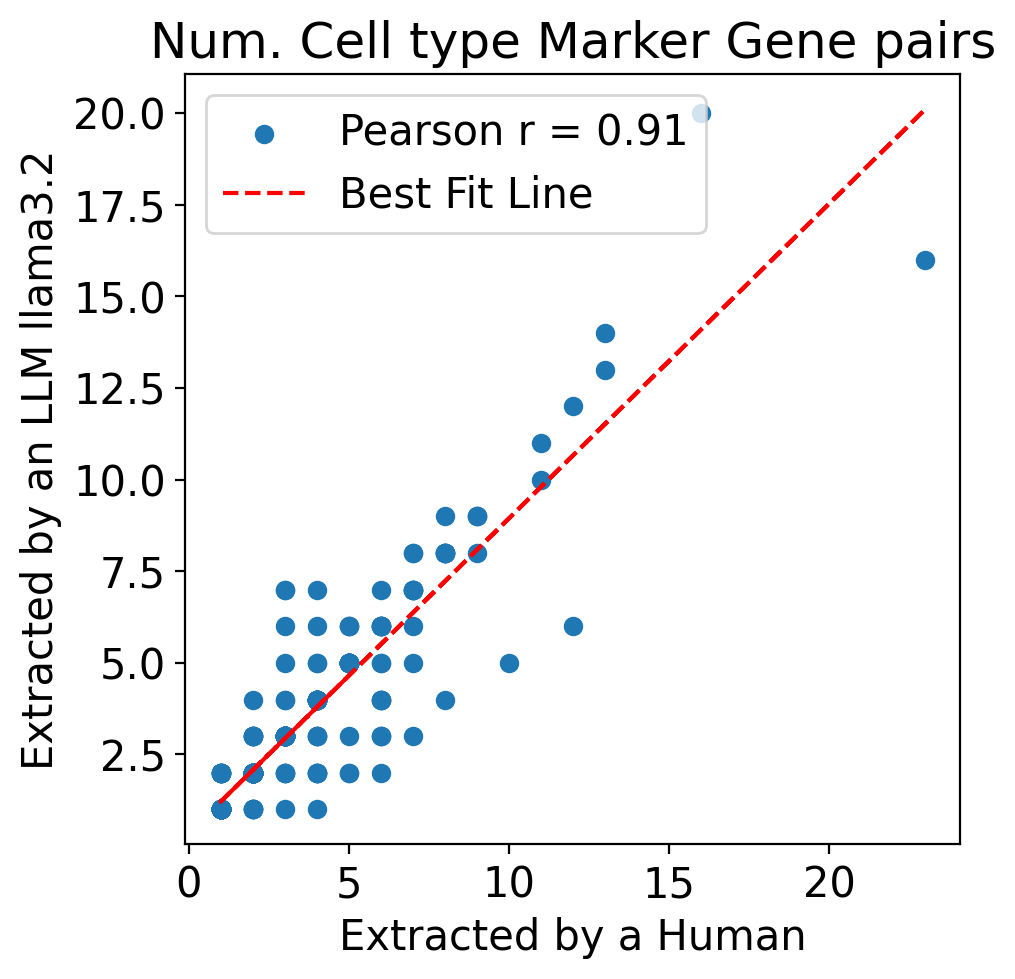

In [130]:
fig, ax = plt.subplots(figsize=(5, 5))

x = hmn.groupby("source_rationale")["extracted_cell_type_label"].count().sort_index()[common_src].values
y = llm.groupby("source_rationale")["extracted_cell_type_label"].count().sort_index()[common_src].values

# Compute Pearson correlation
r, _ = pearsonr(x, y)

# Scatter plot
ax.scatter(x, y, label=f"Pearson r = {r:.2f}")

# Fit line of best fit
m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color='red', linestyle='--', label="Best Fit Line")

# Labels and legend
ax.set(**{
    "xlabel": "Extracted by a Human",
    "ylabel": f"Extracted by an LLM {model_metadata['model_id']}",
    "title": "Num. Cell type Marker Gene pairs"
})
ax.legend()

plt.show()

In [131]:
folder_name

'/Users/sinabooeshaghi/projects/llmarkers/analysis/llm/evidence_llm_llama3.2_MarkerGeneListStrict_4efcc22'

In [132]:
count = pd.DataFrame({"src": common_src, "human": x, "llm": y})
count["same"] = count["human"] == count["llm"]
count.query("same == False")

,src,human,llm,same
0,"Finally, we noted that CALM2 was negatively c...",5,2,False
8,A second immune cell population (cluster 17) s...,6,5,False
14,ANXA1 is a marker of cells undergoing inflamma...,3,2,False
16,Although both cells clusters expressed typical...,6,4,False
17,Although cells in SPG1 and SPG2 are similar to...,8,9,False
...,...,...,...,...
246,"[...] while SIX1+ myoprogenitors (cluster 9),4...",6,3,False
248,and EVT_8W_3 cells displayed a strong similari...,8,4,False
259,"ndeed, TREM2-expressing human LAM cells consti...",7,8,False
260,ndothelial cells could be identified based on ...,2,1,False


In [133]:
count.iloc[0]

src       Finally, we noted that CALM2 was negatively c...
human                                                    5
llm                                                      2
same                                                 False
Name: 0, dtype: object

In [134]:
print(common_src[0])

 Finally, we noted that CALM2 was negatively correlated with BMI in endocrine (α, β, γ, and δ) and ductal cells


In [135]:
src = f"'{common_src[0]}'"

In [136]:
print(src)

' Finally, we noted that CALM2 was negatively correlated with BMI in endocrine (α, β, γ, and δ) and ductal cells'


In [137]:
llm.query(f"source_rationale == {src}")[["extracted_cell_type_label", "extracted_feature_name"]]

,extracted_cell_type_label,extracted_feature_name
911,endocrine,CALM2
912,ductal,CALM2


In [138]:
hmn.query(f"source_rationale == {src}")[["extracted_cell_type_label", "extracted_feature_name", "ds_name", "source_rationale"]]

,extracted_cell_type_label,extracted_feature_name,ds_name,source_rationale
113,ductal cells,CALM2,pancreas_Segerstolpe2016,"Finally, we noted that CALM2 was negatively c..."
114,α endocrine cells,CALM2,pancreas_Segerstolpe2016,"Finally, we noted that CALM2 was negatively c..."
115,β endocrine cells,CALM2,pancreas_Segerstolpe2016,"Finally, we noted that CALM2 was negatively c..."
116,γ endocrine cells,CALM2,pancreas_Segerstolpe2016,"Finally, we noted that CALM2 was negatively c..."
117,δ endocrine cells,CALM2,pancreas_Segerstolpe2016,"Finally, we noted that CALM2 was negatively c..."


# Global comparison

In [139]:
llm.query(f"source_rationale == {src}")

,source_type,source_rationale,source_id,extracted_organism,extracted_cell_type_label,extracted_cell_source,extracted_cell_state,extracted_feature_name,extracted_feature_type,organism,cell_type_id,cell_type_label,cell_source,cell_state,feature_name,feature_type,feature_identifier,feature_identifier_type,ds_name
911,text,"Finally, we noted that CALM2 was negatively c...",text,homo_sapiens,endocrine,None,None,CALM2,gene,homo_sapiens,None,ENDOCRINE,None,None,CALM2,gene,ENSG00000143933,ensembl,llm
912,text,"Finally, we noted that CALM2 was negatively c...",text,homo_sapiens,ductal,None,None,CALM2,gene,homo_sapiens,None,DUCTAL,None,None,CALM2,gene,ENSG00000143933,ensembl,llm


In [140]:
# for each source_rationale, 
# first globally compare the cell types, then genes, 
# then the genes per celltype

feature = "feature_identifier"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
llm_features = pd.Series(llm[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, llm_features)                # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()      # normalized counts
lv, xv, rv  = set_cmp(hmn_features, llm_features, vals=True)  # actual lists

gene_vals = [l,x,r]
gene_nvals = [nl,nx,nr]

print(f"Human v LLM ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")


Human v LLM (feature_identifier)
	left	itx	right
raw	51	597	83
norm	0.07	0.82	0.11


In [141]:
feature = "cell_type_label" # eventually change this to comparing based on a map we can create
# feature = "cell_type_id"

hmn_features = pd.Series(hmn[feature].unique()).dropna().tolist()
llm_features = pd.Series(llm[feature].unique()).dropna().tolist()

l, x, r  = set_cmp(hmn_features, llm_features)               # raw counts
nl, nx, nr = np.array([l,x,r]) / np.array([l,x,r]).sum()     # normalized counts
lv, xv, rv  = set_cmp(hmn_features, llm_features, vals=True) # actual lists

ct_vals = [l,x,r]
ct_nvals = [nl,nx,nr]

print(f"Human v LLM ({feature})")
print("\tleft\titx\tright")
print(f"raw\t{l}\t{x}\t{r}")
print(f"norm\t{nl:.2f}\t{nx:.2f}\t{nr:.2f}")

Human v LLM (cell_type_label)
	left	itx	right
raw	189	52	251
norm	0.38	0.11	0.51


In [142]:
# Define the multi-level column structure and data
columns = pd.MultiIndex.from_product(
    [["cell_type_id", "feature_name"], ["left", "itx", "right"]],
    names=["Feature", "Set Comparison"]
)

data = [
    ct_vals +  gene_vals,  # raw values
   ct_nvals + gene_nvals  # normalized values
]

# Create the DataFrame
df = pd.DataFrame(data, columns=columns, index=["raw", "norm"])



In [143]:
df

Feature        cell_type_id                        feature_name              \
Set Comparison         left        itx       right         left         itx   
raw              189.000000  52.000000  251.000000    51.000000  597.000000   
norm               0.384146   0.105691    0.510163     0.069767    0.816689   

Feature                    
Set Comparison      right  
raw             83.000000  
norm             0.113543

# Global metrics per source rationale

In [117]:
feature = "cell_type_label"
hmn_features = hmn.dropna(subset = [feature]).groupby("source_rationale")[feature].unique()
llm_features = llm.dropna(subset = [feature]).groupby("source_rationale")[feature].unique()

common_src = np.intersect1d(hmn_features.index, llm_features.index)
cmp = pd.DataFrame(index=common_src, columns=["left", "itx", "right"])
for idx, (r1, r2) in enumerate(zip(hmn_features[common_src], llm_features[common_src])):
    l, x, r = set_cmp(r1, r2)
    cmp.iloc[idx] = [l, x, r]

cmp["jac"] = cmp["itx"] / (cmp["left"] + cmp["right"] + cmp["itx"])
cmp_ct = cmp.copy()

In [118]:
feature = "feature_identifier"
hmn_features = hmn.dropna(subset = [feature]).groupby("source_rationale")[feature].unique()
llm_features = llm.dropna(subset = [feature]).groupby("source_rationale")[feature].unique()

common_src = np.intersect1d(hmn_features.index, llm_features.index)
cmp = pd.DataFrame(index=common_src, columns=["left", "itx", "right"])
for idx, (r1, r2) in enumerate(zip(hmn_features[common_src], llm_features[common_src])):
    l, x, r = set_cmp(r1, r2)
    cmp.iloc[idx] = [l, x, r]

cmp["jac"] = cmp["itx"] / (cmp["left"] + cmp["right"] + cmp["itx"])
cmp_gn = cmp.copy()

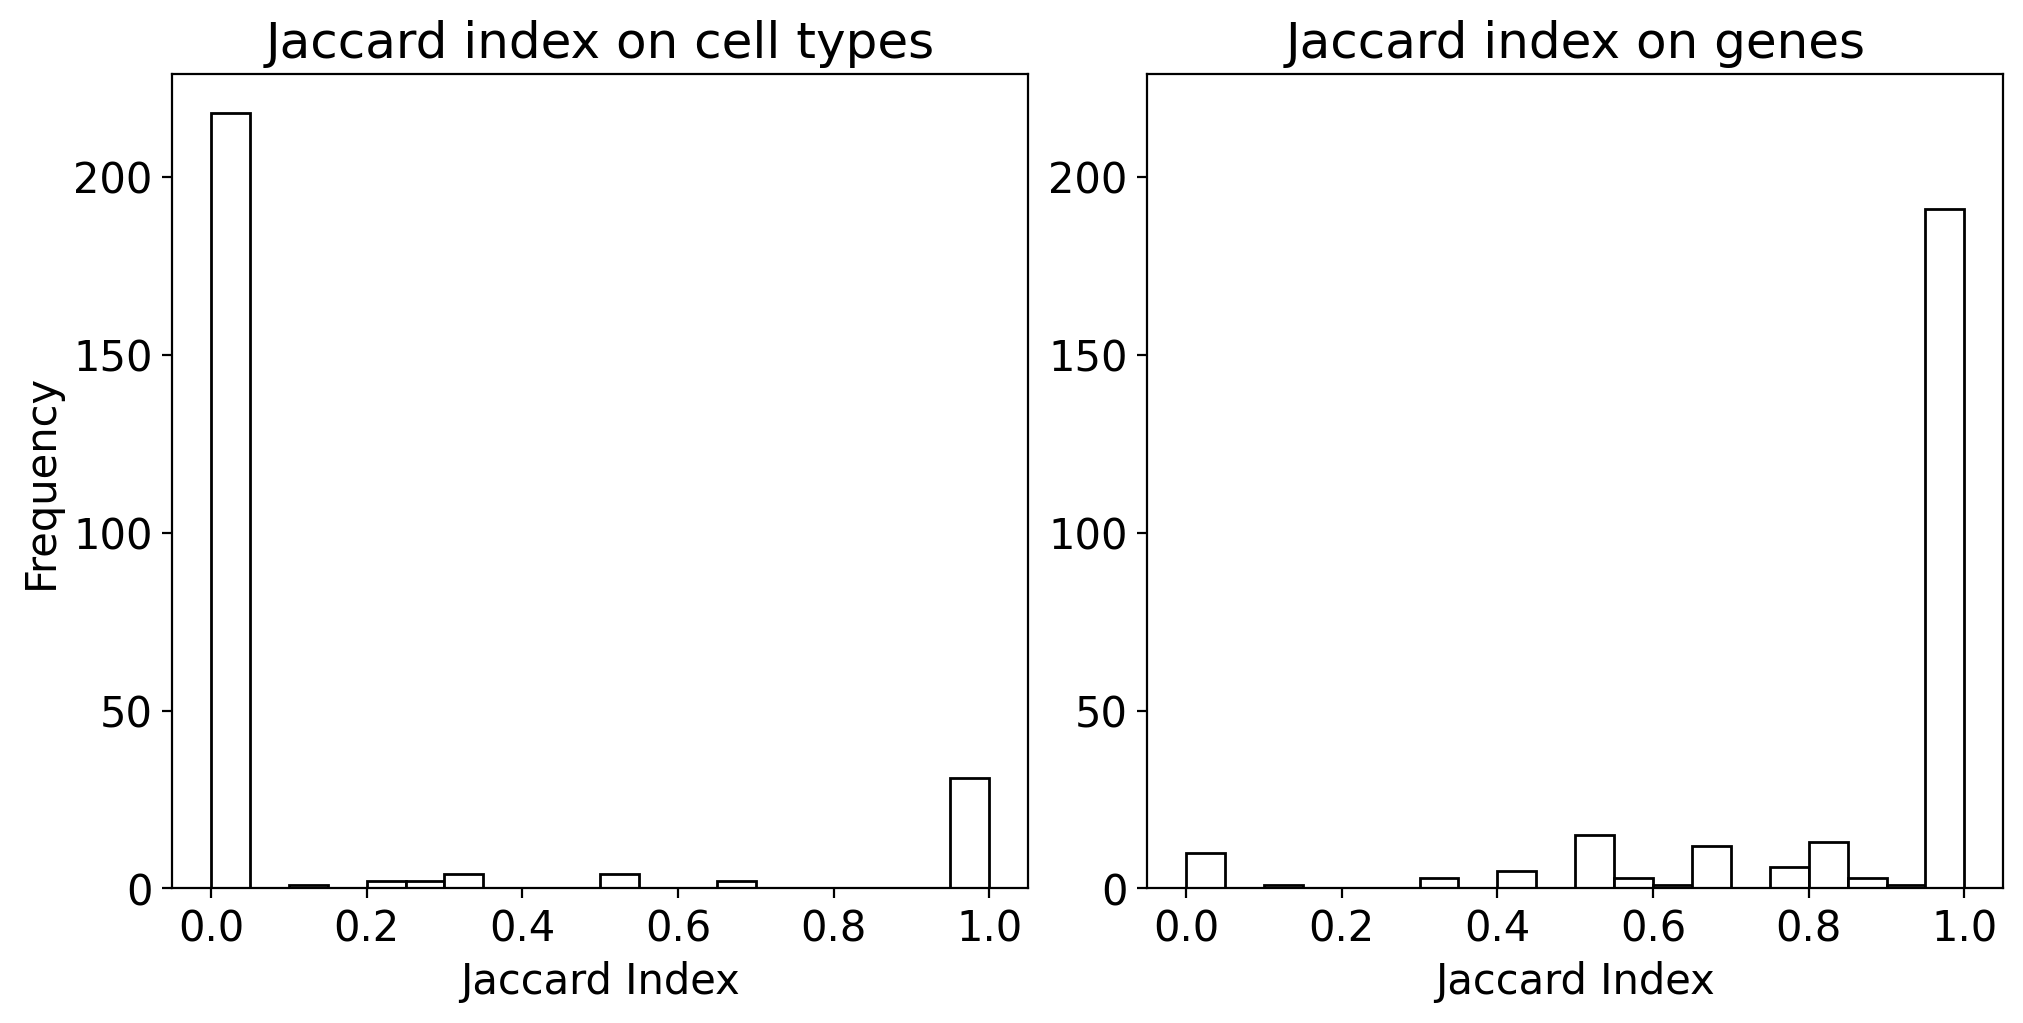

In [ ]:
fig, axs = plt.subplots(figsize=(10, 5), ncols=2, constrained_layout=True)

ax = axs[0]
x = cmp_ct["jac"]
ax.hist(x, bins=20, edgecolor="k", facecolor="white", label="Jaccard Index")
ax.set(**{
    "xlabel": "Jaccard Index",
    "ylabel": "Frequency",
    "title": "Jaccard index on cell types",
})
# ax.legend()

ax = axs[1]
ax.sharey(axs[0])
x = cmp_gn["jac"]
ax.hist(x, bins=20, edgecolor="k", facecolor="white", label="Jaccard Index")
ax.set(**{
    "xlabel": "Jaccard Index",
    "title": "Jaccard index on genes",
})
# ax.legend()
plt.show()